# Training Script for ML Time Series Models

## Settings and Imports

In [ ]:
import os

import torch
import torch.optim as optim
import torch.utils.data as data
import torch.nn as nn

import numpy as np

from utils.data_preparation import prepare_data_for_modeling, create_torch_dataset
from utils.lstm_model import LSTMForecaster

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

BEST_MODEL_PATH = os.path.join("models", "best_lstm_load_forecaster.pt")

REPROCESS_DATA = False

TRAINING = True  # Set to True to train the model
TEST = True  # Set to True to evaluate the model on the test set
BATCH_SIZE = 32
EPOCHS = 3000
LEARNING_RATE = 5e-4
WINDOW_SIZE = 21  # Number of days to look back for the LSTM model
VALIDATE_EVERY = 10
EARLY_STOPPING_PATIENCE = 20
MIN_IMPROVEMENT = 1e-4

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")

# This features describe the today's weather and load.
# Features NOT included:
# - lag and std features, because they are derived from the load feature by the model
# - weather features with low importance according to the XGBoost feature importance plot (e.g. cloud cover, sunshine duration, wind speed, heating/cooling degrees)
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'load']

# These features describe the features of the next day (e.g. holiday and cyclic calendar terms).
FEATURES_TARGET_TIME = ['is_holiday', 'dow_sin',
                        'dow_cos', 'month_sin', 'month_cos']

FEATURES = FEATURES_TODAY + FEATURES_TARGET_TIME

# We will predict the load of the next day
TARGET = "load_t+1"

SCALE_FEATURES = FEATURES_TODAY

Using device: mps


## Dataset Loading and Preparation

In [11]:
data_dict, _ = prepare_data_for_modeling(
    FEATURES, TARGET, SCALE_FEATURES, save_scaler=True, save_data=True,
    train_start_date="2018-01-01", train_end_date="2023-12-31",
    val_start_date="2024-01-01", val_end_date="2024-12-31",
    test_start_date="2025-01-01", test_end_date="2025-12-31",
    reprocess_data=REPROCESS_DATA,
    production_data=False
)

# Target scaling is based on train split only to avoid leakage.
y_train_raw = data_dict['y_train']
y_val_raw = data_dict['y_val']
y_test_raw = data_dict['y_test']

# Scale the target variable using the mean and std of the training target values
target_mean = float(y_train_raw.mean())
target_std = float(y_train_raw.std())
if target_std <= 0:
    raise ValueError("Target standard deviation must be > 0 for scaling.")

y_train = (y_train_raw - target_mean) / target_std
y_val = (y_val_raw - target_mean) / target_std
y_test = (y_test_raw - target_mean) / target_std

print(f"Target scaling -> mean: {target_mean:.2f}, std: {target_std:.2f}")

if TRAINING:
    # Training Data
    X_train_scaled = data_dict['X_train_scaled']
    X_train_tensor, y_train_tensor = create_torch_dataset(
        X=X_train_scaled, y=y_train, window_size=WINDOW_SIZE)
    training_loader = data.DataLoader(data.TensorDataset(
        X_train_tensor, y_train_tensor), shuffle=True, batch_size=BATCH_SIZE)

    # Validation Data
    X_val_scaled = data_dict['X_val_scaled']
    X_val_tensor, y_val_tensor = create_torch_dataset(
        X=X_val_scaled, y=y_val, window_size=WINDOW_SIZE)
    validation_loader = data.DataLoader(data.TensorDataset(
        X_val_tensor, y_val_tensor), shuffle=False, batch_size=BATCH_SIZE)

if TEST:
    # Test Data
    X_test_scaled = data_dict['X_test_scaled']
    X_test_tensor, y_test_tensor = create_torch_dataset(
        X=X_test_scaled, y=y_test, window_size=WINDOW_SIZE)
    test_loader = data.DataLoader(data.TensorDataset(
        X_test_tensor, y_test_tensor), shuffle=False, batch_size=BATCH_SIZE)

    test_df = data_dict['test_df']  # For the timestamps

Target scaling -> mean: 55846.90, std: 6785.10


## Training Setup

In [12]:
model = LSTMForecaster(input_size=len(FEATURES),
                       hidden_size=64, num_layers=1, output_size=1, dropout=0.0).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.SmoothL1Loss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    threshold=MIN_IMPROVEMENT,
    threshold_mode="abs",
)

## Training

In [13]:
if TRAINING:
    best_val_mse = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(EPOCHS):
        model.train()
        train_mse_sum = 0.0
        train_mae_sum = 0.0
        train_samples = 0

        for X_batch, y_batch in training_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            y_pred = model(X_batch).squeeze(-1)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = y_batch.size(0)
            train_samples += batch_size
            train_mse_sum += torch.sum((y_pred - y_batch) ** 2).item()
            train_mae_sum += torch.sum(torch.abs(y_pred - y_batch)).item()

        if epoch % VALIDATE_EVERY != 0:
            continue

        model.eval()
        val_mse_sum = 0.0
        val_mae_sum = 0.0
        val_samples = 0
        val_pred_sum = 0.0
        val_pred_sq_sum = 0.0

        with torch.no_grad():
            for X_batch, y_batch in validation_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                y_pred = model(X_batch).squeeze(-1)

                batch_size = y_batch.size(0)
                val_samples += batch_size
                val_mse_sum += torch.sum((y_pred - y_batch) ** 2).item()
                val_mae_sum += torch.sum(torch.abs(y_pred - y_batch)).item()
                val_pred_sum += torch.sum(y_pred).item()
                val_pred_sq_sum += torch.sum(y_pred ** 2).item()

        train_mse = train_mse_sum / train_samples
        train_rmse = np.sqrt(train_mse)
        train_mae = train_mae_sum / train_samples
        val_mse = val_mse_sum / val_samples
        val_rmse = np.sqrt(val_mse)
        val_mae = val_mae_sum / val_samples

        val_pred_mean = val_pred_sum / val_samples
        val_pred_var = max((val_pred_sq_sum / val_samples) -
                           (val_pred_mean ** 2), 0.0)
        val_pred_std = np.sqrt(val_pred_var)

        scheduler.step(val_mse)

        improved = val_mse < (best_val_mse - MIN_IMPROVEMENT)
        if improved:
            best_val_mse = val_mse
            best_epoch = epoch
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "target_scaled": True,
                    "target_mean": target_mean,
                    "target_std": target_std,
                    "window_size": WINDOW_SIZE,
                    "features": FEATURES,
                },
                BEST_MODEL_PATH,
            )
            epochs_without_improvement = 0
            checkpoint_note = " [saved best]"
        else:
            epochs_without_improvement += 1
            checkpoint_note = ""

        print(
            f"Epoch {epoch}: train RMSE {train_rmse:.4f}, train MAE {train_mae:.4f}, "
            f"val RMSE {val_rmse:.4f}, val MAE {val_mae:.4f}, val MSE {val_mse:.4f}, "
            f"val pred std {val_pred_std:.2f}, lr {optimizer.param_groups[0]['lr']:.2e}{checkpoint_note}"
        )

        if val_pred_std < 0.05:
            print("Warning: validation prediction std is very low; model may be collapsing to near-constant output.")

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping at epoch {epoch}. No sufficient improvement for "
                f"{EARLY_STOPPING_PATIENCE} validation checks."
            )
            break

    print(
        f"Best model saved to {BEST_MODEL_PATH} (epoch {best_epoch}, val MSE {best_val_mse:.6f})")

Epoch 0: train RMSE 0.8921, train MAE 0.7393, val RMSE 0.8348, val MAE 0.5843, val MSE 0.6969, val pred std 0.36, lr 5.00e-04 [saved best]
Epoch 10: train RMSE 0.2805, train MAE 0.1921, val RMSE 0.2662, val MAE 0.1765, val MSE 0.0709, val pred std 0.80, lr 5.00e-04 [saved best]
Epoch 20: train RMSE 0.2210, train MAE 0.1546, val RMSE 0.2163, val MAE 0.1554, val MSE 0.0468, val pred std 0.82, lr 5.00e-04 [saved best]
Epoch 30: train RMSE 0.2011, train MAE 0.1411, val RMSE 0.2061, val MAE 0.1510, val MSE 0.0425, val pred std 0.83, lr 5.00e-04 [saved best]
Epoch 40: train RMSE 0.1919, train MAE 0.1371, val RMSE 0.2045, val MAE 0.1501, val MSE 0.0418, val pred std 0.85, lr 5.00e-04 [saved best]
Epoch 50: train RMSE 0.1815, train MAE 0.1301, val RMSE 0.1943, val MAE 0.1483, val MSE 0.0378, val pred std 0.87, lr 5.00e-04 [saved best]
Epoch 60: train RMSE 0.1785, train MAE 0.1286, val RMSE 0.1891, val MAE 0.1423, val MSE 0.0357, val pred std 0.86, lr 5.00e-04 [saved best]
Epoch 70: train RMSE 

Using target inverse scaling from checkpoint metadata.
Test MAE: 902.24
Test RMSE: 1167.89


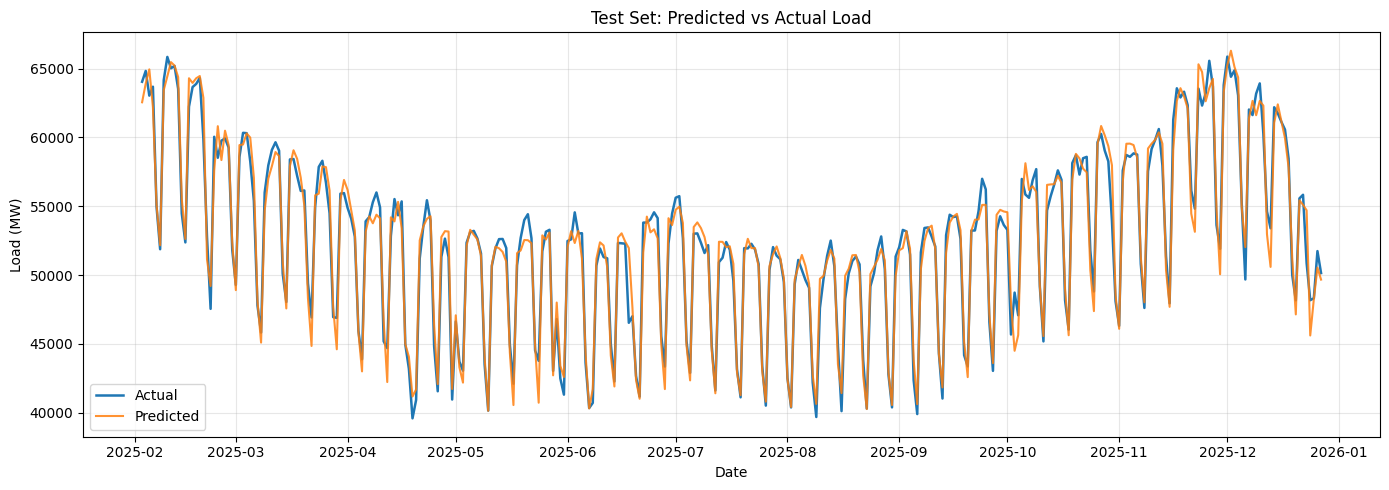

In [14]:
from utils.visualize_model_performance import evaluate_and_plot_model_torch

if TEST:
    if not os.path.exists(BEST_MODEL_PATH):
        raise FileNotFoundError(
            f"Saved model not found at {BEST_MODEL_PATH}. "
            "Run training first with TRAINING=True to create a compatible checkpoint."
        )

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
    checkpoint_target_scaled = False

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model_state_dict = checkpoint["model_state_dict"]
        checkpoint_target_scaled = bool(checkpoint.get("target_scaled", False))
        ckpt_target_mean = float(checkpoint.get("target_mean", target_mean))
        ckpt_target_std = float(checkpoint.get("target_std", target_std))
    else:
        # Backward compatibility for legacy checkpoints saved as raw state_dict.
        model_state_dict = checkpoint
        ckpt_target_mean = target_mean
        ckpt_target_std = target_std

    try:
        model.load_state_dict(model_state_dict)
    except RuntimeError as exc:
        raise RuntimeError(
            "Checkpoint is incompatible with current model/features. "
            "Please retrain with TRAINING=True so a new checkpoint is saved. "
            f"Original error: {exc}"
        ) from exc

    model = model.to(DEVICE)

    if checkpoint_target_scaled:
        eval_target_mean = ckpt_target_mean
        eval_target_std = ckpt_target_std
        print("Using target inverse scaling from checkpoint metadata.")
    else:
        eval_target_mean = None
        eval_target_std = None
        print("Legacy checkpoint detected (no target scaling metadata). Evaluating without inverse scaling.")

    test_predictions_df = evaluate_and_plot_model_torch(
        model=model,
        test_loader=test_loader,
        y_test=y_test if checkpoint_target_scaled else y_test_raw,
        test_df=test_df,
        device=DEVICE,
        window_size=WINDOW_SIZE,
        target_mean=eval_target_mean,
        target_std=eval_target_std,
    )